<a href="https://colab.research.google.com/github/Kemal1101/Model-Comparison-for-Sistem-Tes-Minat-Career/blob/main/Teorema_Bayes_UTS_SBP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# a. **Mengimpor Pustaka**

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# b. **Memuat *Dataset & Pemilihan Data**

In [16]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Kuis_SBP/Preprocessed_RIASEC_Dataset.csv')

X = df.drop('Kategori_Dominan', axis=1)
y = df['Kategori_Dominan']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# c. **Arsitektur Categorical Naive Bayes**

In [17]:
class RIASEC_CategoricalNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha # WBS 1.2.5 Laplace Smoothing
        self.priors = {}
        self.likelihoods = {}
        self.classes = []

    def fit(self, X, y):
        # WBS 1.1: Perhitungan Prior
        self.classes = y.unique()
        n_total = len(y)
        for c in self.classes:
            self.priors[c] = (sum(y == c) + self.alpha) / (n_total + len(self.classes) * self.alpha)

        # WBS 1.2: Perhitungan Likelihood
        self.likelihoods = {c: {} for c in self.classes}
        for c in self.classes:
            X_c = X[y == c]
            for col in X.columns:
                self.likelihoods[c][col] = {}
                counts = X_c[col].value_counts().to_dict()
                for val in range(1, 6): # Skala 1-5
                    self.likelihoods[c][col][val] = (counts.get(val, 0) + self.alpha) / (len(X_c) + self.alpha * 5)

    def predict_posterior(self, x):
        # WBS 2.2: Kalkulasi Posterior
        posteriors = {}
        for c in self.classes:
            log_prob = np.log(self.priors[c])
            for col, val in x.items():
                log_prob += np.log(self.likelihoods[c][col].get(val, 1e-6))
            posteriors[c] = log_prob
        return posteriors

    def get_interest_code(self, x):
        # WBS 2.3 & 3.1: Ekstraksi Top 3 Kode
        posteriors = self.predict_posterior(x)
        sorted_cats = sorted(posteriors.items(), key=lambda item: item[1], reverse=True)
        return "".join([cat for cat, prob in sorted_cats[:3]])

    def predict(self, X):
        return [max(self.predict_posterior(row), key=self.predict_posterior(row).get) for _, row in X.iterrows()]

# d. **Training Model**

In [18]:
model = RIASEC_CategoricalNB(alpha=1.0)
model.fit(X_train, y_train)

# e. **Validasi & Metrik**

In [19]:
y_pred = model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, average='weighted'):.4f}")

Accuracy : 0.2500
Precision: 0.1875
Recall   : 0.2500


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# f. **Plot Confusion Matrix**

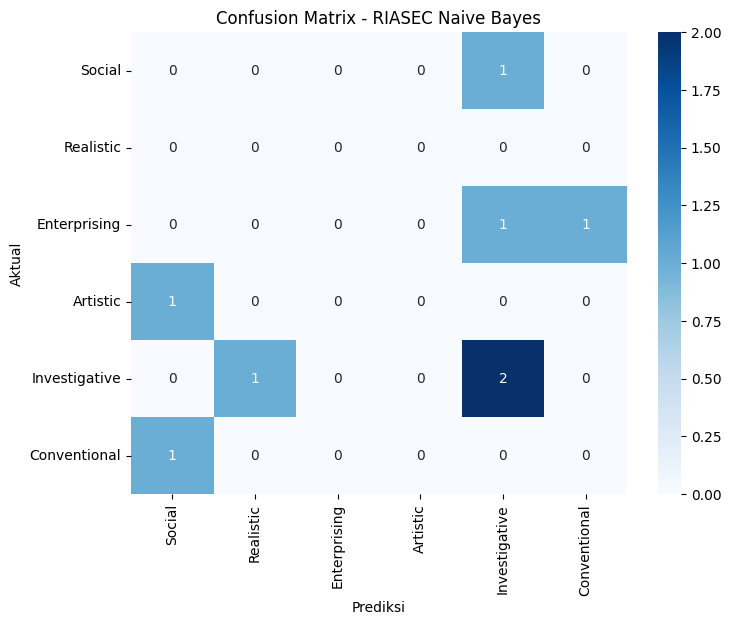

In [20]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes, yticklabels=model.classes, cmap='Blues')
plt.title('Confusion Matrix - RIASEC Naive Bayes')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()